In [3]:
!pip install --quiet matplotlib numpy torch


[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


Original 4x4


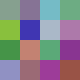

Upsampled 16x16


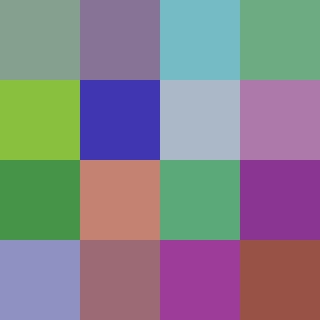

After Convolution


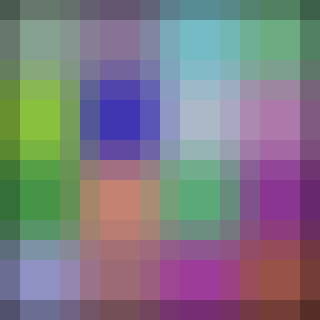

In [23]:
# -----------------------------------------
# Imports & Setup
# -----------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from IPython.display import display

# Fix randomness
np.random.seed(0)
torch.manual_seed(0)

# -----------------------------------------
# Mosaic-style RGB 4x4 Generator
# -----------------------------------------
def generate_mosaic_rgb(size=4, saturation=0.5):
    base = np.random.rand(size, size, 3)
    base = base * saturation + (1 - saturation) * 0.5
    return base.astype(np.float32)

img_small = generate_mosaic_rgb(size=4, saturation=0.6)

# Tensor for processing
img_tensor = torch.tensor(img_small).permute(2, 0, 1).unsqueeze(0)  # [1, 3, 4, 4]

# Upsampling to 16x16
img_up = F.interpolate(img_tensor, size=(16, 16), mode='nearest')

# Convolution (blurring)
conv = nn.Conv2d(3, 3, kernel_size=3, padding=1, bias=False, groups=3)
kernel = torch.tensor([[1, 2, 1],
                       [2, 4, 2],
                       [1, 2, 1]], dtype=torch.float32)
kernel /= kernel.sum()
kernel = kernel.view(1, 1, 3, 3).repeat(3, 1, 1, 1)
conv.weight.data = kernel
img_conv = conv(img_up)

# Convert to numpy
img_np_4x4 = img_small
img_np_16x16 = img_up.squeeze().permute(1, 2, 0).numpy()
img_np_conv = torch.clamp(img_conv.squeeze().permute(1, 2, 0), 0, 1).detach().numpy()

# -----------------------------------------
# Display Function (pixel-size matched, no margin)
# -----------------------------------------

from PIL import Image
from IPython.display import display

def display_image_scaled(img_np, scale=200):
    """
    表示専用。PILを使ってNotebook上に拡大画像を表示（余白なし）。
    
    Parameters:
        img_np: (H, W, 3) float32 ndarray in [0, 1]
        scale: ピクセルごとの拡大倍率（例: 200 → 1ピクセルが200px）
    """
    h, w = img_np.shape[:2]
    img_uint8 = (img_np * 255).clip(0, 255).astype(np.uint8)
    img_resized = Image.fromarray(img_uint8).resize((w * scale, h * scale), Image.NEAREST)
    display(img_resized)

# -----------------------------------------
# Visualization with consistent pixel scale
# -----------------------------------------
print("Original 4x4")
display_image_scaled(img_np_4x4, scale=20)
print("Upsampled 16x16")
display_image_scaled(img_np_16x16, scale=20)
print("After Convolution")
display_image_scaled(img_np_conv, scale=20)

Files already downloaded and verified
Original CIFAR-10 Image (Downsampled to 16x16)


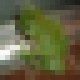

Upsampled Image (64x64, Nearest)


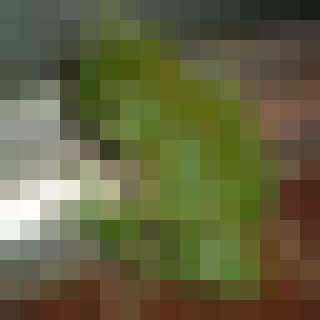

After Convolution (Blurred)


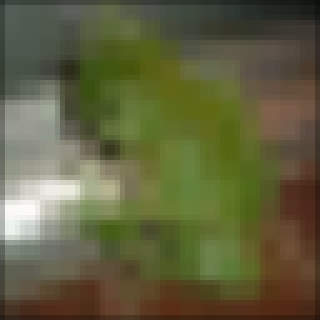

In [33]:
# -----------------------------------------
# Imports & Setup
# -----------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from IPython.display import display
from torchvision.datasets import CIFAR10
from torchvision import transforms

# Fix randomness
np.random.seed(0)
torch.manual_seed(0)

# -----------------------------------------
# Load CIFAR-10 Sample
# -----------------------------------------
transform = transforms.ToTensor()
cifar10 = CIFAR10(root="./data", train=False, download=True, transform=transform)
image_tensor, label = cifar10[7]  # 任意の1枚を取得 (shape [3, 32, 32])

# -----------------------------------------
# Downsample to 16x16
# -----------------------------------------
img_tensor_down = F.interpolate(image_tensor.unsqueeze(0), size=(16, 16), mode='area')  # [1, 3, 16, 16]
img_small = img_tensor_down.squeeze().permute(1, 2, 0).numpy()  # [H, W, C] for display

# Tensor for processing
img_tensor = img_tensor_down  # shape [1, 3, 16, 16]

# Upsampling to 64x64
img_up = F.interpolate(img_tensor, size=(64, 64), mode='nearest')

# Convolution (blurring)
conv = nn.Conv2d(3, 3, kernel_size=3, padding=1, bias=False, groups=3)
kernel = torch.tensor([[1, 2, 1],
                       [2, 4, 2],
                       [1, 2, 1]], dtype=torch.float32)
kernel /= kernel.sum()
kernel = kernel.view(1, 1, 3, 3).repeat(3, 1, 1, 1)
conv.weight.data = kernel
img_conv = conv(img_up)

# Convert to numpy
img_np_16x16 = img_small
img_np_64x64 = img_up.squeeze().permute(1, 2, 0).numpy()
img_np_conv = torch.clamp(img_conv.squeeze().permute(1, 2, 0), 0, 1).detach().numpy()

# -----------------------------------------
# Display Function (pixel-size matched, no margin)
# -----------------------------------------
def display_image_scaled(img_np, scale=10):
    """
    表示専用。PILを使ってNotebook上に拡大画像を表示（余白なし）。
    
    Parameters:
        img_np: (H, W, 3) float32 ndarray in [0, 1]
        scale: ピクセルごとの拡大倍率（例: 200 → 1ピクセルが200px）
    """
    h, w = img_np.shape[:2]
    img_uint8 = (img_np * 255).clip(0, 255).astype(np.uint8)
    img_resized = Image.fromarray(img_uint8).resize((w * scale, h * scale), Image.NEAREST)
    display(img_resized)

# -----------------------------------------
# Visualization
# -----------------------------------------
print("Original CIFAR-10 Image (Downsampled to 16x16)")
display_image_scaled(img_np_16x16, scale=5)

print("Upsampled Image (64x64, Nearest)")
display_image_scaled(img_np_64x64, scale=5)

print("After Convolution (Blurred)")
display_image_scaled(img_np_conv, scale=5)